# 03 — Fluency features from VAD

Goal: turn each recording into a fixed set of interpretable timing features that describe
*how* the person spoke, independent of *what* they said.

All features derive from energy-based VAD (text-independent), so they stay reliable on
disfluent speech where forced alignment breaks down. These features are the input to the
fluency model in notebook 04.

In [7]:
import numpy as np

def extract_fluency_features(audio, sr, text):
    """Compute interpretable timing/pause features from one recording.
    All timing is derived from energy VAD (text-independent), so it stays valid even when
    forced alignment fails on disfluent speech. Word counts for rate features come from the
    known reference text, which is reliable regardless of alignment quality.

    Edge silence (before the first / after the last speech frame) is trimmed before computing
    ratios and rates: it reflects when 'record' was pressed, not the speaker's fluency.
    Onset latency is kept separately as its own feature.
    """
    v = detect_pauses(audio, sr)
    frame_s = 0.025
    is_speech = v["is_speech"]
    t = v["t"]
    total_dur = len(audio) / sr

    speech_idx = np.where(is_speech)[0]
    if len(speech_idx) == 0:
        # No speech detected — return a neutral/empty feature set instead of crashing.
        return dict(speech_rate=0.0, articulation_rate=0.0, phonation_ratio=0.0,
                    n_pauses=0, pause_time=0.0, pause_ratio=0.0, mean_pause=0.0,
                    max_pause=0.0, n_long_pauses=0, onset_latency=total_dur,
                    span_time=0.0, total_dur=total_dur)

    first, last = speech_idx[0], speech_idx[-1]

    # Edge silences, kept out of the ratios (onset is also a feature on its own).
    onset_latency = t[first]

    # Spoken span = first speech frame -> last speech frame (edges removed).
    span_time = (last - first + 1) * frame_s
    # Phonation time = actual speech within that span (excludes internal pauses).
    phonation_time = int(is_speech[first:last + 1].sum()) * frame_s

    # Internal pauses only (detect_pauses already bounds these by speech on both sides).
    pause_durs = [d for _, d in v["pauses"]]
    pause_time = sum(pause_durs)

    # Word count from the KNOWN reference text -> reliable, not aligner-dependent.
    n_words = len(text.split())

    return {
        # --- rate (words per second) ---
        "speech_rate":       n_words / span_time if span_time > 0 else 0.0,        # incl. internal pauses
        "articulation_rate": n_words / phonation_time if phonation_time > 0 else 0.0,  # excl. pauses

        # --- phonation (edge-clean now) ---
        "phonation_ratio":   phonation_time / span_time if span_time > 0 else 0.0,

        # --- pausing ---
        "n_pauses":          len(pause_durs),
        "pause_time":        pause_time,
        "pause_ratio":       pause_time / span_time if span_time > 0 else 0.0,
        "mean_pause":        float(np.mean(pause_durs)) if pause_durs else 0.0,
        "max_pause":         float(np.max(pause_durs)) if pause_durs else 0.0,
        "n_long_pauses":     sum(1 for d in pause_durs if d >= 0.5),

        # --- onset (edge, kept as its own signal) ---
        "onset_latency":     onset_latency,

        # --- context (not features; for analysis / deriving rates) ---
        "span_time":         span_time,
        "total_dur":         total_dur,
    }

In [5]:
def detect_pauses(audio, sr, frame_ms=25, sil_ratio=0.30, min_pause_s=0.25):
    """Text-independent pause detection via RMS-energy VAD.
    Unlike forced alignment, this stays reliable on disfluent speech because it
    doesn't assume the audio matches any reference text.

    - sil_ratio: threshold placed between noise floor (p10) and speech level (p90),
      so it adapts to each recording's gain instead of a fixed global cutoff.
    - min_pause_s: silences shorter than this are not counted as pauses (250 ms is
      a common threshold in the fluency literature).
    Returns per-frame arrays plus the list of internal pauses and onset latency.
    """
    fl = int(frame_ms / 1000 * sr)
    rms = np.array([np.sqrt(np.mean(audio[i:i+fl]**2)) for i in range(0, len(audio)-fl, fl)])
    t = np.arange(len(rms)) * (frame_ms / 1000)

    floor, peak = np.percentile(rms, 10), np.percentile(rms, 90)
    thresh = floor + sil_ratio * (peak - floor)
    is_speech = rms > thresh

    # Onset latency = leading silence before the first speech frame.
    speech_idx = np.where(is_speech)[0]
    if len(speech_idx) == 0:
        return dict(t=t, rms=rms, is_speech=is_speech, pauses=[], onset=t[-1])
    onset = t[speech_idx[0]]

    # Internal pauses = silence runs bounded by speech on both sides, long enough to count.
    pauses = []
    i = speech_idx[0]
    while i <= speech_idx[-1]:
        if not is_speech[i]:
            j = i
            while j <= speech_idx[-1] and not is_speech[j]:
                j += 1
            dur = (j - i) * (frame_ms / 1000)
            if dur >= min_pause_s:
                pauses.append((t[i], dur))
            i = j
        else:
            i += 1
    return dict(t=t, rms=rms, is_speech=is_speech, pauses=pauses, onset=onset)

In [3]:
# Notebook 03 runs in a fresh kernel, so re-load everything it needs.
# (Notebooks don't share variables — each starts clean.)
import numpy as np
from datasets import load_dataset

train = load_dataset("mispeech/speechocean762", split="train", trust_remote_code=True)

# Rebuild the fluency index lists (same as notebook 02).
# NOTE: HF datasets rejects numpy integer types as indices — cast with int() when using them.
fluency_col = train["fluency"]
low_idx  = [i for i, f in enumerate(fluency_col) if f <= 3]
high_idx = [i for i, f in enumerate(fluency_col) if f >= 9]
print(f"{len(low_idx)} low-fluency (<=3), {len(high_idx)} high-fluency (>=9)")

/Users/rnorel/.pyenv/versions/3.11.14/envs/fluency-from-alignment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


33 low-fluency (<=3), 870 high-fluency (>=9)


In [6]:
for tag, idx in [("LOW  fluency=3", int(low_idx[0])), ("HIGH fluency=9", int(high_idx[0]))]:
    ex = train[idx]
    feats = extract_fluency_features(np.asarray(ex["audio"]["array"], np.float32),
                                     ex["audio"]["sampling_rate"])
    print(f"\n{tag}:")
    for k, val in feats.items():
        print(f"  {k:18s} {val:.3f}")


LOW  fluency=3:
  phonation_ratio    0.484
  n_pauses           5.000
  pause_time         3.700
  pause_ratio        0.216
  mean_pause         0.740
  max_pause          1.100
  n_long_pauses      4.000
  onset_latency      1.700
  total_dur          17.106

HIGH fluency=9:
  phonation_ratio    0.329
  n_pauses           1.000
  pause_time         0.275
  pause_ratio        0.107
  mean_pause         0.275
  max_pause          0.275
  n_long_pauses      0.000
  onset_latency      0.600
  total_dur          2.580


In [8]:
for tag, idx in [("LOW  fluency=3", int(low_idx[0])), ("HIGH fluency=9", int(high_idx[0]))]:
    ex = train[idx]
    feats = extract_fluency_features(np.asarray(ex["audio"]["array"], np.float32),
                                     ex["audio"]["sampling_rate"], ex["text"])
    print(f"\n{tag}:")
    for k, val in feats.items():
        print(f"  {k:18s} {val:.3f}")


LOW  fluency=3:
  speech_rate        0.743
  articulation_rate  1.208
  phonation_ratio    0.615
  n_pauses           5.000
  pause_time         3.700
  pause_ratio        0.275
  mean_pause         0.740
  max_pause          1.100
  n_long_pauses      4.000
  onset_latency      1.700
  span_time          13.450
  total_dur          17.106

HIGH fluency=9:
  speech_rate        3.019
  articulation_rate  4.706
  phonation_ratio    0.642
  n_pauses           1.000
  pause_time         0.275
  pause_ratio        0.208
  mean_pause         0.275
  max_pause          0.275
  n_long_pauses      0.000
  onset_latency      0.600
  span_time          1.325
  total_dur          2.580


In [9]:
import pandas as pd
from tqdm import tqdm

def build_feature_table(dataset):
    """Extract fluency features for every utterance in a split -> DataFrame.
    Keeps the human fluency label (and demographics) alongside the features so the
    modeling notebook can correlate/validate directly.
    """
    rows = []
    for ex in tqdm(dataset, desc="extracting features"):
        audio = np.asarray(ex["audio"]["array"], np.float32)
        feats = extract_fluency_features(audio, ex["audio"]["sampling_rate"], ex["text"])
        feats["fluency"] = ex["fluency"]     # target
        feats["age"]     = ex["age"]         # for later child-vs-adult checks
        feats["gender"]  = ex["gender"]
        rows.append(feats)
    return pd.DataFrame(rows)

# Build for both splits and cache to parquet (cheap to recompute, but caching keeps things tidy).
train_feats = build_feature_table(train)
train_feats.to_parquet("../data/train_features.parquet")

test = load_dataset("mispeech/speechocean762", split="test", trust_remote_code=True)
test_feats = build_feature_table(test)
test_feats.to_parquet("../data/test_features.parquet")

print("train:", train_feats.shape, "| test:", test_feats.shape)
train_feats.head()


extracting features: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:01<00:00, 1375.04it/s]

train: (2500, 15) | test: (2500, 15)


,speech_rate,articulation_rate,phonation_ratio,n_pauses,pause_time,pause_ratio,mean_pause,max_pause,n_long_pauses,onset_latency,span_time,total_dur,fluency,age,gender
0,3.018868,4.705882,0.641509,1,0.275,0.207547,0.275,0.275,0,0.600,1.325,2.580,9,6,m
1,1.975309,2.622951,0.753086,1,0.275,0.135802,0.275,0.275,0,0.750,2.025,3.430,9,6,m
2,1.904762,2.909091,0.654762,1,0.275,0.130952,0.275,0.275,0,0.625,2.100,3.350,10,6,m
3,1.333333,2.222222,0.600000,2,0.700,0.311111,0.350,0.425,0,0.650,2.250,3.319,9,6,m
4,2.424242,3.809524,0.636364,0,0.000,0.000000,0.000,0.000,0,0.675,1.650,3.010,9,6,m


In [10]:
from scipy.stats import spearmanr

# Correlate each feature with the human fluency score across the full training set.
# Spearman (rank-based) matches our decision to treat fluency as ordinal/continuous.
# Expected signs: pause features NEGATIVE (more pausing -> lower fluency),
#                 rate features POSITIVE (faster reading -> higher fluency).
feature_cols = ["speech_rate", "articulation_rate", "phonation_ratio",
                "n_pauses", "pause_time", "pause_ratio", "mean_pause",
                "max_pause", "n_long_pauses", "onset_latency"]

corr = []
for col in feature_cols:
    rho, p = spearmanr(train_feats[col], train_feats["fluency"])
    corr.append({"feature": col, "spearman_rho": rho, "p_value": p})

corr_df = pd.DataFrame(corr).sort_values("spearman_rho", key=abs, ascending=False)
print(corr_df.to_string(index=False))

          feature  spearman_rho       p_value
      speech_rate      0.641993 1.602986e-290
       pause_time     -0.591659 5.112829e-236
        max_pause     -0.575644 1.266505e-220
         n_pauses     -0.572550 9.538577e-218
       mean_pause     -0.553634 8.276254e-201
    n_long_pauses     -0.547869 7.368317e-196
      pause_ratio     -0.533668 4.514135e-184
articulation_rate      0.531613 2.057353e-182
  phonation_ratio      0.463495 2.226747e-133
    onset_latency      0.103387  2.211311e-07


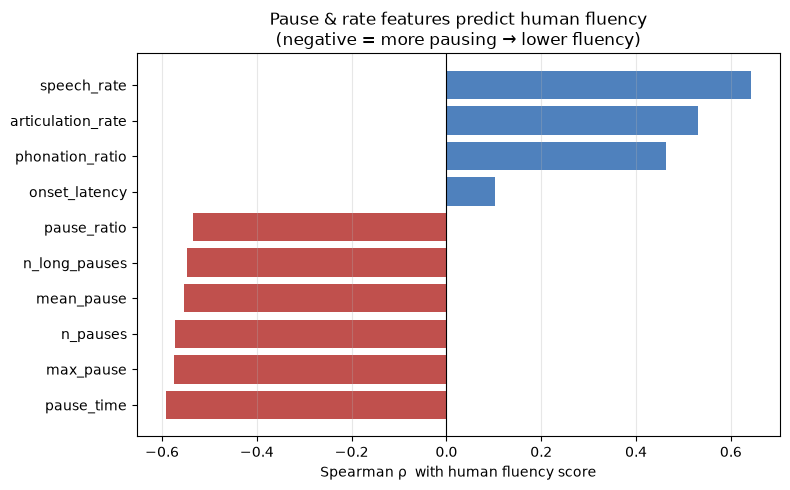

In [11]:
import matplotlib.pyplot as plt

# Horizontal bar chart of Spearman rho per feature, colored by sign.
# Red = negative (pausing hurts fluency), blue = positive (rate/phonation help).
plot_df = corr_df.sort_values("spearman_rho")   # ascending, so strongest negatives on top
colors = ["#c0504d" if r < 0 else "#4f81bd" for r in plot_df["spearman_rho"]]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["spearman_rho"], color=colors)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Spearman ρ  with human fluency score")
plt.title("Pause & rate features predict human fluency\n(negative = more pausing → lower fluency)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/feature_correlations.png", dpi=130, bbox_inches="tight")
plt.show()

## Takeaways

All features correlate with human fluency in the expected direction (rate features
positive, pause features negative), and all are highly significant across 2,500 utterances:

- **`speech_rate` (ρ = 0.64)** is the single strongest predictor — reading speed dominates.
  It outranks `articulation_rate` (ρ = 0.53) even though the latter removes pauses,
  suggesting pausing is part of the fluency signal, not noise to strip out.
- **Pause features are consistently negative** (ρ from −0.53 to −0.59): more/longer pauses
  → lower fluency. These come from VAD, not alignment — validating the design switch.
- **`onset_latency` (ρ = 0.10)** barely matters: how long before someone starts speaking
  says little about how fluently they read.

Crucially, these pause features are text-independent (VAD-based), so they remain valid on
exactly the disfluent utterances where forced alignment fails.